In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from sklearn.datasets import fetch_olivetti_faces
olivetti = fetch_olivetti_faces()
print(olivetti.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

In [3]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=52)
train_i, test_i = next(strat_split.split(olivetti.data, olivetti.target))

X_train = olivetti.data[train_i]
y_train = olivetti.target[train_i]

X_test = olivetti.data[test_i]
y_test = olivetti.target[test_i]

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=80, random_state=52)
train_i, valid_i = next(strat_split.split(X_train, y_train))

X_train = olivetti.data[train_i]
y_train = olivetti.target[train_i]

X_valid = olivetti.data[valid_i]
y_valid = olivetti.target[valid_i]

X_train.shape

(280, 4096)

In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99, random_state=52)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

X_train_pca.shape

(280, 199)

[[115.           0.20913064]]


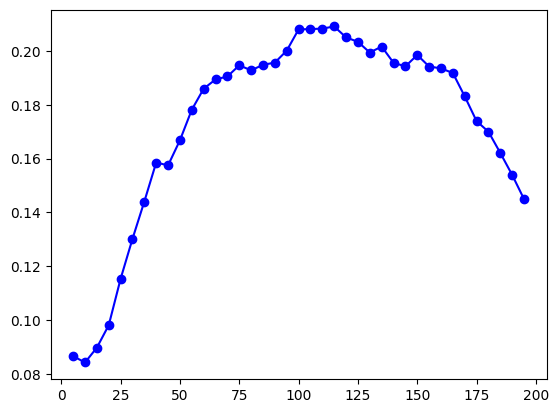

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

table = []

for k in range(5, 200, 5):
    kmean = KMeans(n_clusters=k, random_state=52)
    kmean.fit(X_train_pca)
    table.append([k, silhouette_score(X_train_pca, kmean.labels_)])
    
    
table = np.array(table)
plt.plot(table[:, 0], table[:, 1], "bo-")

print(table[table[:, 1] == table[:, 1].max()])


In [6]:
kmodel = KMeans(n_clusters=115, random_state=52)
kmodel.fit(X_train_pca)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",115
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",52
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


Cluster:  0


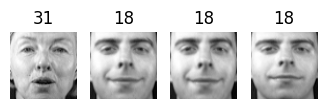

Cluster:  1


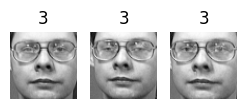

Cluster:  2


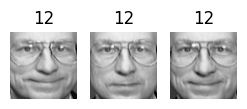

Cluster:  3


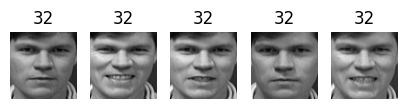

Cluster:  4


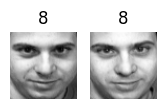

Cluster:  5


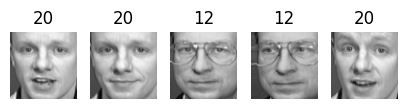

Cluster:  6


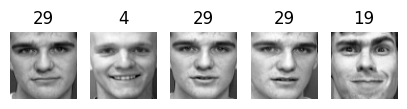

Cluster:  7


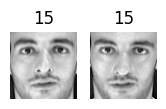

Cluster:  8


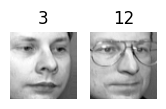

Cluster:  9


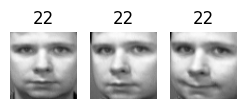

Cluster:  10


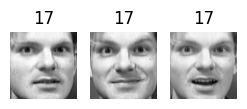

Cluster:  11


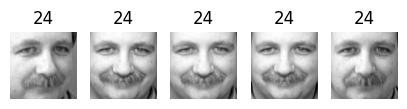

Cluster:  12


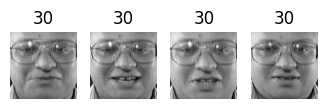

Cluster:  13


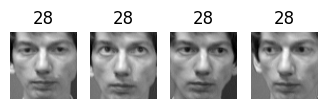

Cluster:  14


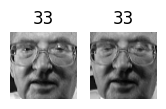

Cluster:  15


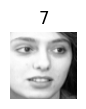

Cluster:  16


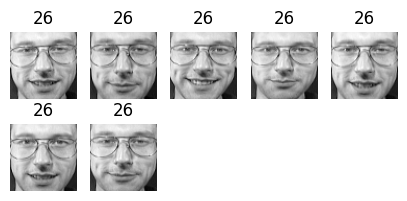

Cluster:  17


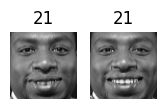

Cluster:  18


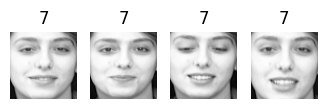

Cluster:  19


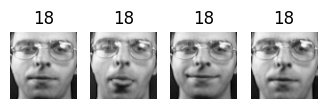

Cluster:  20


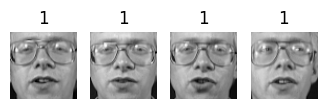

Cluster:  21


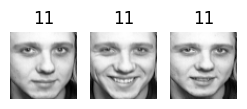

Cluster:  22


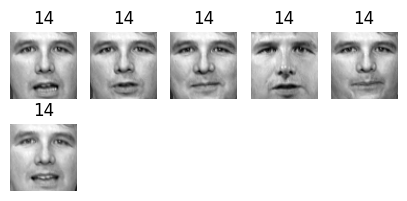

Cluster:  23


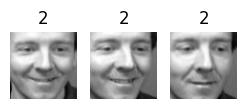

Cluster:  24


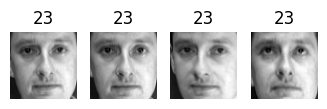

Cluster:  25


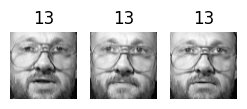

Cluster:  26


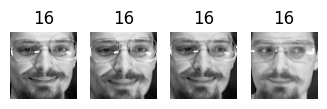

Cluster:  27


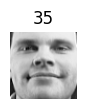

Cluster:  28


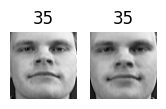

Cluster:  29


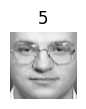

Cluster:  30


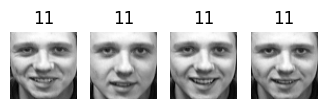

Cluster:  31


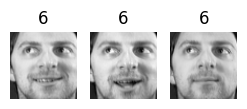

Cluster:  32


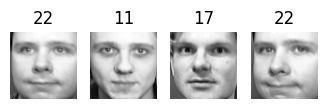

Cluster:  33


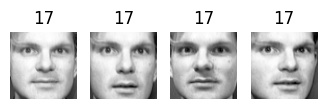

Cluster:  34


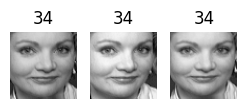

Cluster:  35


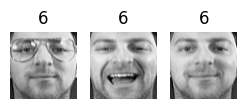

Cluster:  36


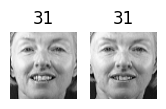

Cluster:  37


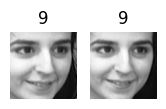

Cluster:  38


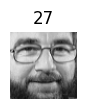

Cluster:  39


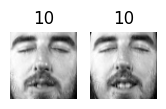

Cluster:  40


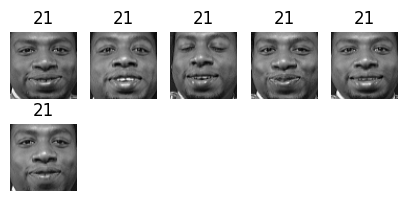

Cluster:  41


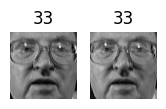

Cluster:  42


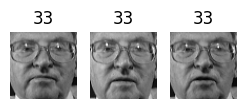

Cluster:  43


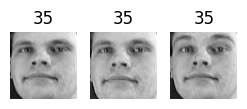

Cluster:  44


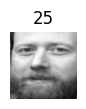

Cluster:  45


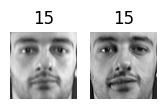

Cluster:  46


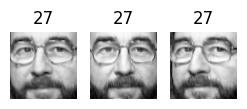

Cluster:  47


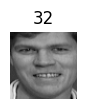

Cluster:  48


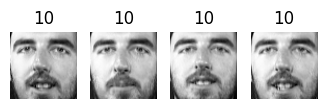

Cluster:  49


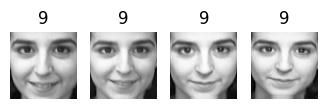

Cluster:  50


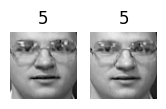

Cluster:  51


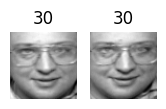

Cluster:  52


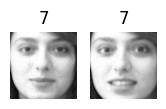

Cluster:  53


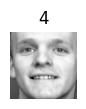

Cluster:  54


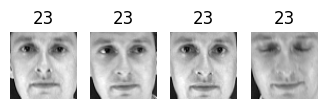

Cluster:  55


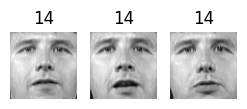

Cluster:  56


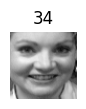

Cluster:  57


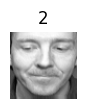

Cluster:  58


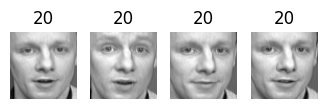

Cluster:  59


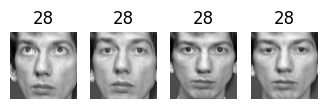

Cluster:  60


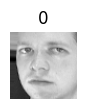

Cluster:  61


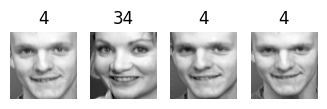

Cluster:  62


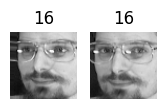

Cluster:  63


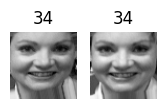

Cluster:  64


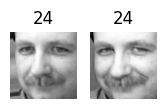

Cluster:  65


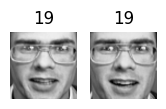

Cluster:  66


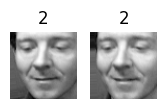

Cluster:  67


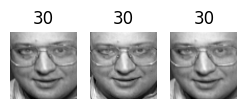

Cluster:  68


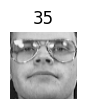

Cluster:  69


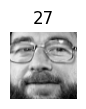

Cluster:  70


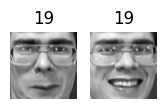

Cluster:  71


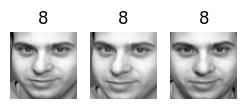

Cluster:  72


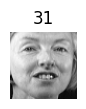

Cluster:  73


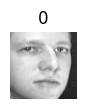

Cluster:  74


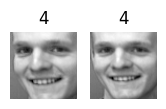

Cluster:  75


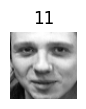

Cluster:  76


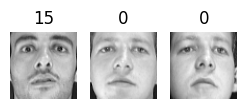

Cluster:  77


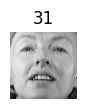

Cluster:  78


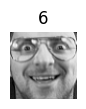

Cluster:  79


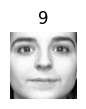

Cluster:  80


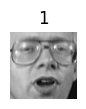

Cluster:  81


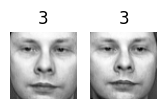

Cluster:  82


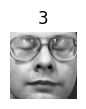

Cluster:  83


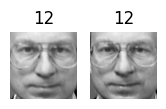

Cluster:  84


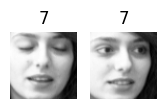

Cluster:  85


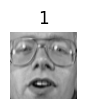

Cluster:  86


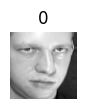

Cluster:  87


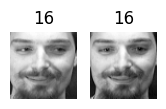

Cluster:  88


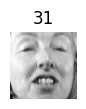

Cluster:  89


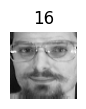

Cluster:  90


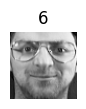

Cluster:  91


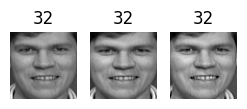

Cluster:  92


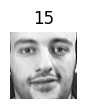

Cluster:  93


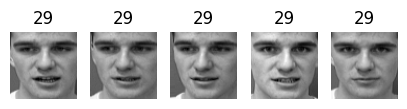

Cluster:  94


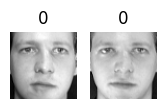

Cluster:  95


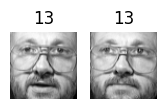

Cluster:  96


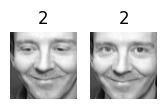

Cluster:  97


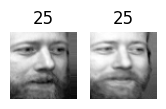

Cluster:  98


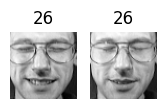

Cluster:  99


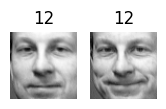

Cluster:  100


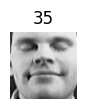

Cluster:  101


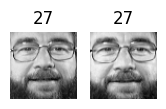

Cluster:  102


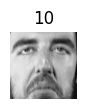

Cluster:  103


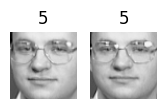

Cluster:  104


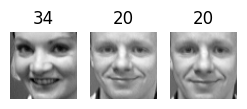

Cluster:  105


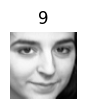

Cluster:  106


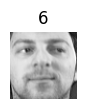

Cluster:  107


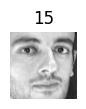

Cluster:  108


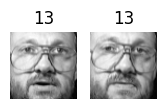

Cluster:  109


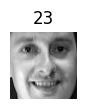

Cluster:  110


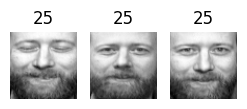

Cluster:  111


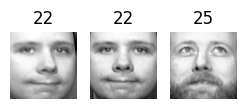

Cluster:  112


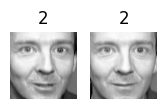

Cluster:  113


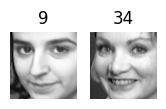

Cluster:  114


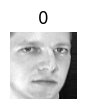

In [7]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces)-1)//n_cols+1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index+1)
        plt.imshow(face, cmap="gray")
        plt.axis('off')
        plt.title(label)
    plt.show()
    
    
for cluster_id in np.unique(kmodel.labels_):
    print("Cluster: ", cluster_id)
    in_cluster = kmodel.labels_==cluster_id
    faces=X_train[in_cluster]
    labels=y_train[in_cluster]
    plot_faces(faces, labels)

### Ex 11

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=140,random_state=52)
rf.fit(X_train_pca, y_train)
rf.score(X_valid_pca, y_valid)

0.9375

In [19]:
X_train_reduced = kmodel.fit_transform(X_train_pca)
X_valid_reduced = kmodel.transform(X_valid_pca)

rf_c = RandomForestClassifier(n_estimators=140,random_state=52)
rf_c.fit(X_train_reduced, y_train)
rf_c.score(X_valid_reduced, y_valid)

0.7625

In [23]:
from sklearn.pipeline import make_pipeline
maax = 0
maax_i = 0

for n in range(5, 200):
    pipem = make_pipeline(KMeans(n_clusters=n, random_state=52), RandomForestClassifier(n_estimators=140, random_state=52))
    pipem.fit(X_train_pca, y_train)
    score = pipem.score(X_valid_pca, y_valid)
    print(n, score)
    if(maax<score):
        maax=score
        maax_i = n
        
print("Maximum is ", maax_i, maax)

5 0.4125
6 0.5
7 0.525
8 0.5
9 0.5875
10 0.6
11 0.6
12 0.625
13 0.6
14 0.625
15 0.6625
16 0.5875
17 0.65
18 0.6375
19 0.6625
20 0.6375
21 0.675
22 0.5875
23 0.6375
24 0.625
25 0.65
26 0.625
27 0.6625
28 0.725
29 0.6875
30 0.6875
31 0.675
32 0.6875
33 0.7625
34 0.7875
35 0.75
36 0.725
37 0.725
38 0.7125
39 0.775
40 0.75
41 0.7375
42 0.725
43 0.7625
44 0.7375
45 0.725
46 0.7125
47 0.75
48 0.7625
49 0.7
50 0.7375
51 0.7375
52 0.7625
53 0.75
54 0.7125
55 0.7875
56 0.775
57 0.7625
58 0.7875
59 0.7125
60 0.8
61 0.825
62 0.7625
63 0.7625
64 0.7375
65 0.775
66 0.7375
67 0.7875
68 0.75
69 0.75
70 0.7875
71 0.8
72 0.775
73 0.775
74 0.75
75 0.7875
76 0.7625
77 0.7875
78 0.775
79 0.7625
80 0.775
81 0.7375
82 0.7625
83 0.775
84 0.7625
85 0.8
86 0.7875
87 0.775
88 0.8
89 0.7875
90 0.775
91 0.775
92 0.775
93 0.7875
94 0.775
95 0.775
96 0.775
97 0.75
98 0.775
99 0.825
100 0.75
101 0.75
102 0.8
103 0.8125
104 0.8
105 0.825
106 0.7875
107 0.7875
108 0.7625
109 0.775
110 0.7125
111 0.75
112 0.7625
113 0.

In [24]:
X_train_extended = np.c_[X_train_pca, X_train_reduced]
X_valid_extended = np.c_[X_valid_pca, X_valid_reduced]

r_clf = RandomForestClassifier(n_estimators=140, random_state=52)
r_clf.fit(X_train_extended, y_train)
r_clf.score(X_valid_extended, y_valid)

0.8375

### Ex 12

In [26]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=40, random_state=52)
y_train_pred = gm.fit_predict(X_train_pca)

/home/damian/test/test/lib/python3.14/site-packages/sklearn/mixture/_base.py:468: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))


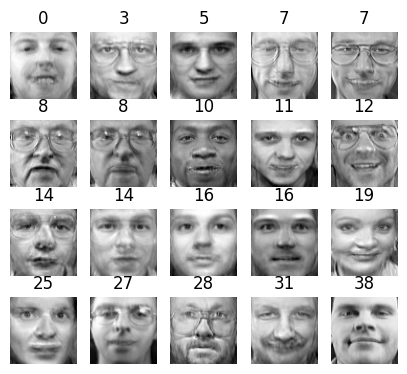

In [27]:
gen_faces, y_gen_faces = gm.sample(n_samples=20)
gen_faces = pca.inverse_transform(gen_faces)

plot_faces(gen_faces, y_gen_faces)

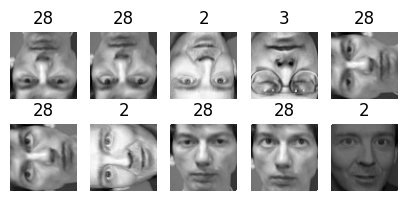

In [54]:
#flipped
flipped = X_train[:4].copy()
flipped = flipped.reshape((-1, 64, 64))[:, ::-1]
flipped = flipped.reshape((4, -1))

#rotated
rotated = X_train[:3].copy()
rotated = rotated.reshape((-1, 64, 64))
rotated = np.transpose(rotated, axes=[0, 2, 1])
rotated = rotated.reshape((3, -1))

#darkened
darkened = X_train[:3].copy()
darkened[:, 1:-1] *= 0.3

#
X_bad = np.r_[flipped, rotated, darkened]
y_bad = np.r_[y_train[:4], y_train[:3], y_train[:3]]

plot_faces(X_bad, y_bad)

In [66]:
X_bad_pca = pca.transform(X_bad)

print(np.mean(gm.score_samples(X_bad_pca)))
print(np.mean(gm.score_samples(X_train_pca)))

#gm.score_samples(X_bad)

-5.3532536e+07
1129.1622


### Ex 13

In [70]:
def reconstruction_error(pca, X):
    X_reduced = pca.transform(X)
    X_reconstructed = pca.inverse_transform(X_reduced)
    mse = np.square((X - X_reconstructed)).mean(axis=-1)
    return mse

print(reconstruction_error(pca, X_train).mean())
print(reconstruction_error(pca, X_bad).mean())

0.00018742502
0.0046877386


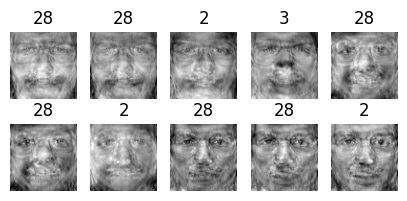

In [71]:
X_bad_reconstructed = pca.inverse_transform(X_bad_pca)
plot_faces(X_bad_reconstructed, y_bad)